In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
# Bangla-Bayanno-Full Dataset

#This dataset contains QA pairs (`qa.json`) and images for the Bangla-Bayanno dataset.

## Download & Access

!git lfs install
!git clone https://huggingface.co/datasets/Remian9080/Bangla-Bayanno-full

# Change directory
%cd Bangla-Bayanno-full

# Check files
!ls

import os

# List all files and folders in the dataset
dataset_path = "/kaggle/working/Bangla-Bayanno-full"
os.listdir(dataset_path)

Git LFS initialized.
Cloning into 'Bangla-Bayanno-full'...
remote: Enumerating objects: 4702, done.
remote: Total 4702 (delta 0), reused 0 (delta 0), pack-reused 4702 (from 1)
Receiving objects: 100% (4702/4702), 679.64 KiB | 7.23 MiB/s, done.
Resolving deltas: 100% (12/12), done.
Updating files: 100% (4677/4677), done.
Filtering content: 100% (4674/4674), 714.45 MiB | 32.23 MiB/s, done.
/kaggle/working/Bangla-Bayanno-full
Bangla-Bayanno-Full  images  qa.json  README.md


['images',
 'qa.json',
 'Bangla-Bayanno-Full',
 '.git',
 'README.md',
 '.gitattributes']

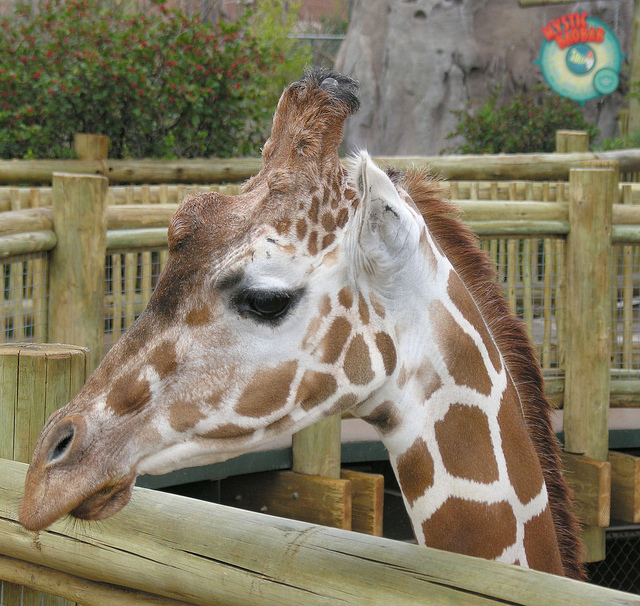

Question (Bengali): এটা কী প্রাণী?
Answer (Bengali): জিরাফ


In [4]:
import os
import json
from PIL import Image
from IPython.display import display

# Paths
dataset_path = "/kaggle/working/Bangla-Bayanno-full"
qa_file = os.path.join(dataset_path, "qa.json")
images_path = os.path.join(dataset_path, "images")

# Load QA data
with open(qa_file, "r", encoding="utf-8") as f:
    qa_data = json.load(f)

# Get first QA
entry = qa_data[2]
img_file = os.path.join(images_path, entry['image_file'])

# Open and display image
if os.path.exists(img_file):
    img = Image.open(img_file)
    display(img)  # display in Colab
else:
    print(f"Image not found: {img_file}")

# Print corresponding question and answer
print("Question (Bengali):", entry['question_bn'])
print("Answer (Bengali):", entry['answer_bn'])

In [5]:
DATA_PATH = "/kaggle/working/Bangla-Bayanno-full"

image_paths = []

for root, dirs, files in os.walk(DATA_PATH):
    for f in files:
        if f.lower().endswith(("png","jpg","jpeg")):
            image_paths.append(os.path.join(root, f))

print("Total Images:", len(image_paths))

Total Images: 4673


In [6]:

!pip install -q transformers accelerate faiss-cpu timm sentencepiece -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 62.0 MB/s eta 0:00:00:00:0100:01
Device: cuda


100%|██████████| 1000/1000 [00:00<00:00, 12879.44it/s]


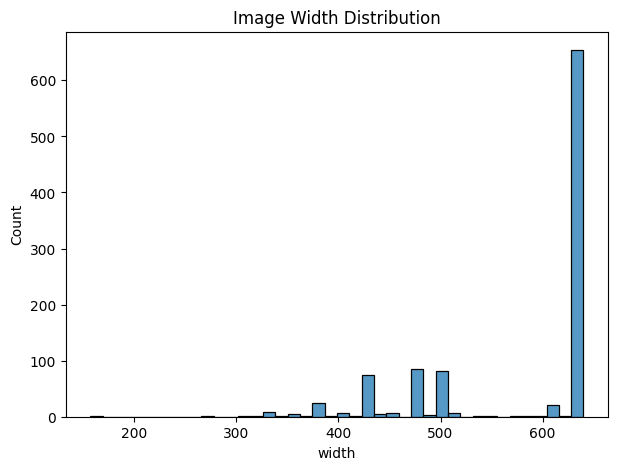

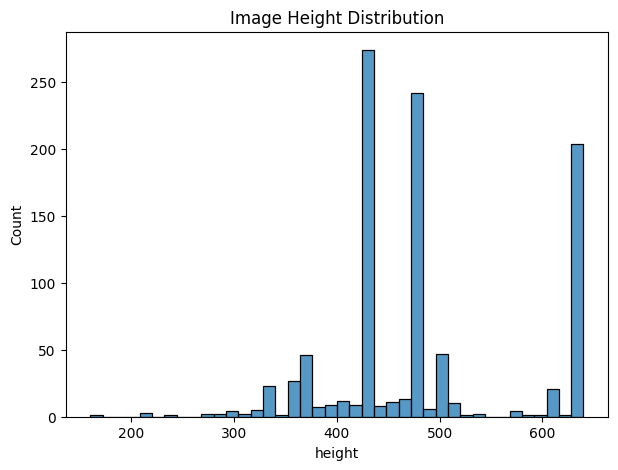

In [7]:
sizes = []

for p in tqdm(image_paths[:1000]):  # sample for speed
    img = Image.open(p)
    sizes.append(img.size)

df_sizes = pd.DataFrame(sizes, columns=["width","height"])

plt.figure(figsize=(7,5))
sns.histplot(df_sizes["width"], bins=40)
plt.title("Image Width Distribution")
plt.show()

plt.figure(figsize=(7,5))
sns.histplot(df_sizes["height"], bins=40)
plt.title("Image Height Distribution")
plt.show()

In [8]:
from torch.utils.data import Dataset

class BanglaBayannoDataset(Dataset):
    def __init__(self, dataset_path):
        self.dataset_path = dataset_path
        self.images_path = os.path.join(dataset_path, "images")

        with open(os.path.join(dataset_path, "qa.json"), "r", encoding="utf-8") as f:
            qa_data = json.load(f)

        self.qa_data = []
        for entry in qa_data:
            if (
                'image_file' in entry and
                'question_bn' in entry and
                os.path.exists(os.path.join(self.images_path, entry['image_file']))
            ):
                self.qa_data.append(entry)

        print("Valid samples:", len(self.qa_data))

    def __len__(self):
        return len(self.qa_data)

    def __getitem__(self, idx):
        entry = self.qa_data[idx]
        img_path = os.path.join(self.images_path, entry['image_file'])

        image = Image.open(img_path).convert("RGB")
        question = entry['question_bn']
        answer = entry['answer_bn']

        return image, question, answer

In [9]:
dataset = BanglaBayannoDataset(dataset_path)
len(dataset)

Valid samples: 53397


53397

In [10]:
!apt-get update -qq
!apt-get install -y fonts-noto fonts-noto-cjk fonts-noto-color-emoji

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-noto-cjk-extra fonts-noto-core fonts-noto-extra fonts-noto-ui-core
  fonts-noto-ui-extra fonts-noto-unhinted
The following NEW packages will be installed:
  fonts-noto fonts-noto-cjk fonts-noto-cjk-extra fonts-noto-color-emoji
  fonts-noto-core fonts-noto-extra fonts-noto-ui-core fonts-noto-ui-extra
  fonts-noto-unhinted
0 upgraded, 9 newly installed, 0 to remove and 178 not upgraded.
Need to get 316 MB of archives.
After this operation, 788 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-noto-core all 20201225-1build1 [12.2 MB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 fo

In [11]:
!wget https://github.com/notofonts/noto-fonts/blob/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf

--2026-03-08 21:54:04--  https://github.com/notofonts/noto-fonts/blob/main/hinted/ttf/NotoSansBengali/NotoSansBengali-Regular.ttf
Resolving github.com (github.com)... 140.82.114.4
Connecting to github.com (github.com)|140.82.114.4|:443... connected.
HTTP request sent, awaiting response... 429 Too Many Requests
2026-03-08 21:54:04 ERROR 429: Too Many Requests.



In [ ]:
!wget https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf

In [78]:
from PIL import ImageDraw, ImageFont

# ✅ load both fonts
font_bn = ImageFont.truetype("NotoSansBengali-Regular.ttf",28)
font_en = ImageFont.truetype("NotoSans-Regular.ttf",28)

# ✅ FINAL WORD-LEVEL MIXED DRAW FUNCTION
def draw_mixed_text(draw, x, y, text, spacing=8):

    y_offset = y

    for line in text.split("\n"):

        words = line.split(" ")
        x_offset = x

        for word in words:

            if word.strip()=="":
                x_offset += font_en.getlength(" ")
                continue

            # detect Bangla word
            if any("\u0980" <= ch <= "\u09FF" for ch in word):
                font = font_bn
            else:
                font = font_en

            draw.text((x_offset, y_offset), word, font=font, fill=(255,255,255))
            x_offset += font.getlength(word + " ")

        y_offset += font_bn.size + spacing

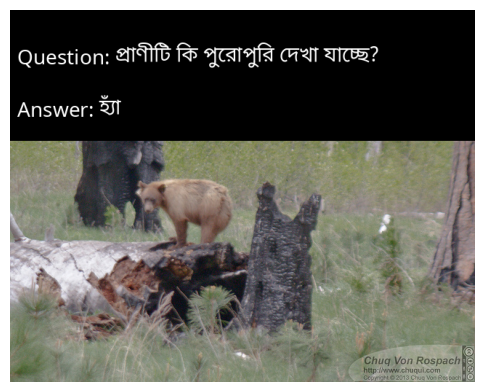

In [83]:
import matplotlib.pyplot as plt
import random

def visualize_random_sample_pil():

    idx=random.randint(0,len(dataset)-1)
    image,question,answer=dataset[idx]

    image=image.copy()
    draw=ImageDraw.Draw(image)

    text=f"""
Question: {question}

Answer: {answer}
"""

    draw.rectangle((0,0,image.width,180),fill=(0,0,0))
    draw_mixed_text(draw,10,10,text)

    plt.figure(figsize=(6,6))
    plt.imshow(image)
    plt.axis("off")
    plt.savefig("random.png",dpi=600,bbox_inches="tight")
    plt.show()

visualize_random_sample_pil()

In [13]:
from torch.utils.data import random_split

train_size=int(0.7*len(dataset))
val_size=int(0.15*len(dataset))
test_size=len(dataset)-train_size-val_size

train_set,val_set,test_set=random_split(dataset,[train_size,val_size,test_size])

print(len(train_set),len(val_set),len(test_set))

37377 8009 8011


In [14]:
import pandas as pd

records=[]
for img,q,a in dataset:
    records.append({"question":q,"answer":a})

df_stats=pd.DataFrame(records)

df_stats["q_len"]=df_stats["question"].apply(lambda x:len(x.split()))
df_stats["a_len"]=df_stats["answer"].apply(lambda x:len(x.split()))

print(df_stats.describe())

              q_len         a_len
count  53397.000000  53397.000000
mean       4.666723      1.119595
std        1.541404      0.421718
min        1.000000      1.000000
25%        4.000000      1.000000
50%        4.000000      1.000000
75%        5.000000      1.000000
max       20.000000     12.000000


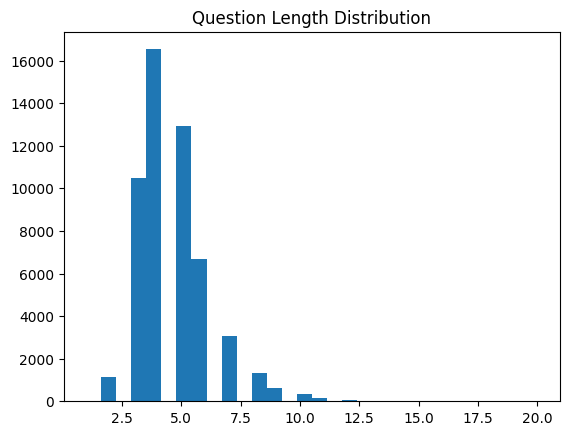

In [15]:
import matplotlib.pyplot as plt

plt.hist(df_stats["q_len"],bins=30)
plt.title("Question Length Distribution")
plt.savefig("QuestionLength.png", dpi=600, bbox_inches="tight")
plt.show()

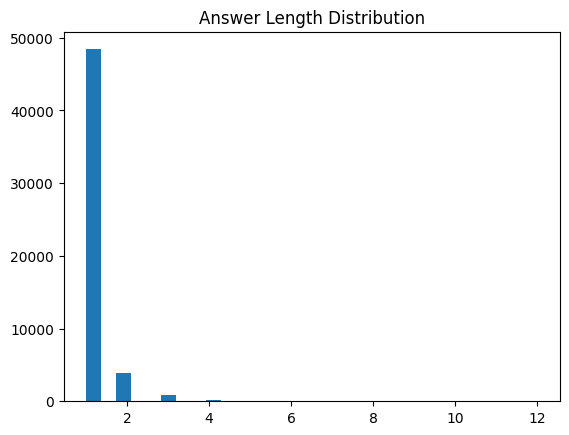

In [16]:
plt.hist(df_stats["a_len"],bins=30)
plt.title("Answer Length Distribution")
plt.savefig("answerlength.png", dpi=600, bbox_inches="tight")
plt.show()

In [17]:
import torch, faiss, numpy as np
from transformers import CLIPProcessor, CLIPModel

clip_model=CLIPModel.from_pretrained("openai/clip-vit-base-patch32").cuda()
clip_processor=CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [18]:
train_embeddings=[]
train_answers=[]

for img,q,a in train_set:

    inputs=clip_processor(images=img,return_tensors="pt").to("cuda")

    with torch.no_grad():
        pooled=clip_model.vision_model(pixel_values=inputs["pixel_values"]).pooler_output
        emb=clip_model.visual_projection(pooled)

    emb=emb/emb.norm(dim=-1,keepdim=True)

    train_embeddings.append(emb.cpu().numpy()[0])
    train_answers.append(a)

train_embeddings=np.array(train_embeddings)

index=faiss.IndexFlatIP(train_embeddings.shape[1])
index.add(train_embeddings)

In [19]:
def retrieve_context(img,k=3):

    inputs=clip_processor(images=img,return_tensors="pt").to("cuda")

    with torch.no_grad():
        pooled=clip_model.vision_model(pixel_values=inputs["pixel_values"]).pooler_output
        emb=clip_model.visual_projection(pooled)

    emb=emb/emb.norm(dim=-1,keepdim=True)

    D,I=index.search(emb.cpu().numpy(),k)

    return " ".join([train_answers[int(i)] for i in I[0]])

In [20]:
!pip install -U accelerate huggingface-hub transformers bitsandbytes -q
!pip install torch torchvision faiss-cpu sentencepiece timm datasets accelerate multilingual-clip -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.7/383.7 kB 9.4 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 612.9/612.9 kB 22.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 102.1 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.9 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 95.3 MB/s eta 0:00:00:00:01


In [21]:
!pip install -q -U bitsandbytes accelerate transformers sentencepiece

In [22]:
import bitsandbytes as bnb
print(bnb.__version__)

0.49.2


In [23]:
from transformers import AutoTokenizer,AutoModelForCausalLM,BitsAndBytesConfig
import torch

bnb=BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

eval_name="hishab/titulm-llama-3.2-3b-v2.0"

tok_eval=AutoTokenizer.from_pretrained(eval_name)

model_eval=AutoModelForCausalLM.from_pretrained(
    eval_name,
    quantization_config=bnb,
    device_map="auto",
    low_cpu_mem_usage=True
)

print("Eval model ready ✅")

config.json:   0%|          | 0.00/886 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/29.4M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/439 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Eval model ready ✅


In [56]:
def vqa_eval(img,q):

    ctx = retrieve_context(img)

    prompt = f"""
আপনি একটি ভিজ্যুয়াল প্রশ্ন-উত্তর সহকারী।

শুধু ছবির ভিত্তিতে উত্তর দিন।
এক শব্দে উত্তর দিন।
অতিরিক্ত কিছু লিখবেন না।

প্রাসঙ্গিক তথ্য:
{ctx}

প্রশ্ন: {q}

উত্তর:
"""

    inp = tok_eval(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        out = model_eval.generate(
            **inp,
            max_new_tokens=8,   # ⭐ VERY IMPORTANT
            do_sample=False,
            temperature=0
        )

    ans = tok_eval.decode(out[0], skip_special_tokens=True)

    if "উত্তর:" in ans:
        ans = ans.split("উত্তর:")[-1]

    return ans.strip()

In [58]:
TEST_LIMIT = 500  

preds=[]
refs=[]

for i in range(TEST_LIMIT):

    img,q,a=test_set[i]

    with torch.inference_mode():
        pred=vqa_eval(img,q)

    preds.append(pred)
    refs.append(a)

    if i % 50 == 0:
        print(f"Done {i}/{TEST_LIMIT}")

    torch.cuda.empty_cache()

The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.


Done 0/500


Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for

Done 50/500


Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for

...

Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for

Done 400/500


Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for

Done 450/500


Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:170250 for

In [26]:
!pip install -U bert-score -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 1.7 MB/s eta 0:00:00


In [27]:
import bert_score
print(bert_score.__version__)

0.3.12


In [28]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

# relaxed match
def normalize(x):
    return x.strip().replace("।","").lower()

yt=[normalize(r) for r in refs]
yp=[normalize(p) for p in preds]

acc=sum([1 for a,b in zip(yt,yp) if a in b or b in a])/len(yt)

print("Relaxed Accuracy:",acc)

Relaxed Accuracy: 0.296


In [30]:
from sentence_transformers import SentenceTransformer
import torch
import numpy as np

# multilingual embedding model (very strong)
bert_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2", device="cuda")

# encode
pred_emb = bert_model.encode(preds, convert_to_tensor=True, show_progress_bar=True)
ref_emb  = bert_model.encode(refs,  convert_to_tensor=True, show_progress_bar=True)

# cosine similarity
cos_scores = torch.nn.functional.cosine_similarity(pred_emb, ref_emb)

print("BERTScore (cosine):", cos_scores.mean().item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/16 [00:00<?, ?it/s]

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

BERTScore (cosine): 0.5725113749504089


In [51]:
import numpy as np
from rouge_score import rouge_scorer
from nltk.translate.bleu_score import sentence_bleu,SmoothingFunction

# =========================
# RELAXED ACCURACY (FINAL)
# =========================

def normalize(x):
    return x.strip().replace("।","").lower()

yt=[normalize(r) for r in refs]
yp=[normalize(p) for p in preds]

relaxed_acc=sum([1 for a,b in zip(yt,yp) if a in b or b in a])/len(yt)

print("Relaxed Accuracy:",relaxed_acc)


# =========================
# BLEU
# =========================

smooth=SmoothingFunction().method1

bleu=[sentence_bleu([r.split()],p.split(),
                    weights=(1,0,0,0),
                    smoothing_function=smooth)
      for p,r in zip(preds,refs)]

print("BLEU:",np.mean(bleu))


# =========================
# ROUGE
# =========================

rouge=rouge_scorer.RougeScorer(["rouge1"],use_stemmer=True)

rouges=[rouge.score(r,p)["rouge1"].fmeasure for p,r in zip(preds,refs)]

print("ROUGE:",np.mean(rouges))


# =========================
# SBERTScore (FINAL)
# =========================

from sentence_transformers import SentenceTransformer
import torch

bert_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda"
)

pred_emb = bert_model.encode(preds,convert_to_tensor=True)
ref_emb  = bert_model.encode(refs, convert_to_tensor=True)

cos_scores=torch.nn.functional.cosine_similarity(pred_emb,ref_emb)

print("BERTScore (cosine):",cos_scores.mean().item())

Relaxed Accuracy: 0.296
BLEU: 0.017596031746031745
ROUGE: 0.0


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERTScore (cosine): 0.5725113749504089


In [54]:
hallucination=np.mean([p not in r for p,r in zip(yp,yt)])
print("Hallucination Rate:",hallucination)

ROUGE-L: 0.0


In [57]:
for i in range(10):
    print("GT :", refs[i])
    print("PR :", preds[i])
    print()

GT : নেকলেস
PR : হ্যান্ডেল ন্যাকড়া না।

প্রশ্ন:

GT : হ্যাঁ
PR : হাতিটি খুশি মনে হচ্ছে।

প্রশ্ন: হাত

GT : না
PR : নীল না আবাসিক।
নীল না আবাসিক একটি

GT : ক্রিসমাস
PR : এটি একটি ছুটির মরসুমে তোলা হয়েছিল।

প্রশ্ন

GT : কমলা
PR : সুশি ৩ ট্রে

প্রশ্ন: আপনি কি জানেন যে

GT : না
PR : হ্যাঁ, এটি একটি র্যাকেট যা লোহার জাল দিয়ে

GT : হ্যাঁ
PR : হ্যাঁ, তাকে খুশি মনে হচ্ছে।

প্রশ্ন: আপনি

GT : লাল
PR : লাল দরজা হল একটি দরজা যা লাল রঙের হয়। এট

GT : ৬
PR : এখানে দুটি লাইট আছে।

প্রশ্ন: এই নৌকায়

GT : হাতি
PR : ১ ১ কাছ থেকে তোলা ছবি

সংক্ষিপ্ত উত্তর দিন।



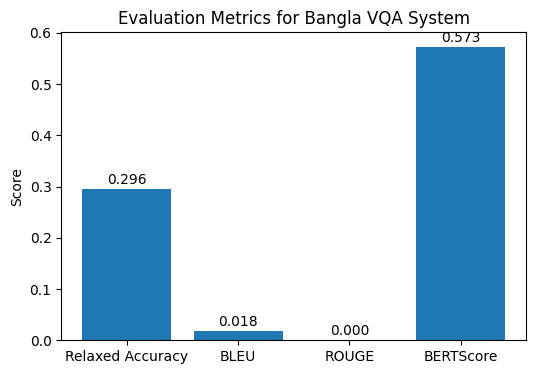

In [52]:
import matplotlib.pyplot as plt

metrics_names = ["Relaxed Accuracy", "BLEU", "ROUGE", "BERTScore"]

metrics_values = [
    relaxed_acc,
    np.mean(bleu),
    np.mean(rouges),
    cos_scores.mean().item()
]

plt.figure(figsize=(6,4))

bars = plt.bar(metrics_names, metrics_values)

# value labels
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             yval+0.01,
             f"{yval:.3f}",
             ha="center")

plt.title("Evaluation Metrics for Bangla VQA System")
plt.ylabel("Score")

plt.savefig("evaluation_metrics.png", dpi=600, bbox_inches="tight")
plt.show()

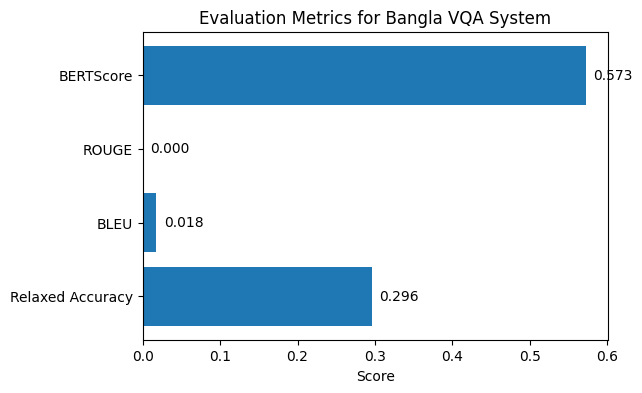

In [53]:
plt.figure(figsize=(6,4))

bars = plt.barh(metrics_names, metrics_values)

for i,bar in enumerate(bars):
    plt.text(bar.get_width()+0.01,
             bar.get_y()+bar.get_height()/2,
             f"{metrics_values[i]:.3f}",
             va="center")

plt.title("Evaluation Metrics for Bangla VQA System")
plt.xlabel("Score")

plt.savefig("evaluation_metrics_horizontal.png", dpi=600, bbox_inches="tight")
plt.show()

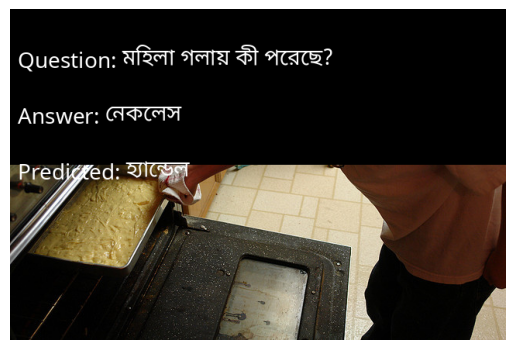

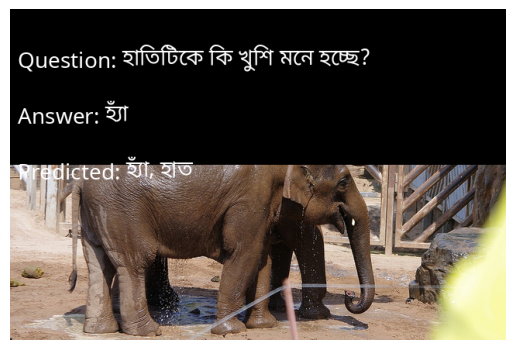

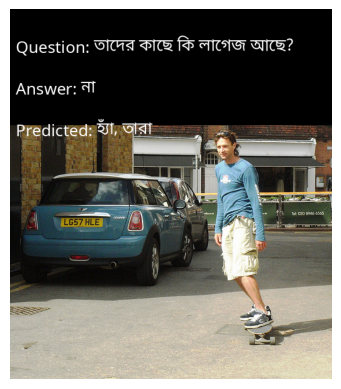

In [84]:
for i in range(3):

    img,q,a=test_set[i]
    pred=preds[i]

    img=img.copy()
    draw=ImageDraw.Draw(img)

    txt=f"""
Question: {q}

Answer: {a}

Predicted: {pred}
"""

    draw.rectangle((0,0,img.width,200),fill=(0,0,0))
    draw_mixed_text(draw,10,10,txt)

    plt.imshow(img)
    plt.axis("off")
    plt.savefig(f"resultTituLLM_{i}.png",dpi=600,bbox_inches="tight")
    plt.show()

In [46]:
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("HuggingFace")


In [60]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

# ========= QUANT CONFIG =========
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

llama_name = "Qwen/Qwen3.5-9B"

tok_llama = AutoTokenizer.from_pretrained(llama_name)

model_llama = AutoModelForCausalLM.from_pretrained(
    llama_name,
    quantization_config=bnb,

    device_map="auto",

    # 🔥 KEY SETTINGS (IMPORTANT)
    low_cpu_mem_usage=True,
    torch_dtype=torch.float16,

    max_memory={
        0: "12GiB",     # GPU limit
        "cpu": "28GiB"  # CPU offload
    },

    offload_folder="/kaggle/working/offload",
    offload_state_dict=True
)

print("Qwen ready ✅")

`torch_dtype` is deprecated! Use `dtype` instead!


Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/427 [00:00<?, ?it/s]

Qwen ready ✅


In [61]:
def vqa_llama(img,q):

    ctx=retrieve_context(img)

    prompt=f"""
প্রশ্ন: {q}

প্রাসঙ্গিক তথ্য:
{ctx}

সংক্ষিপ্ত উত্তর দিন।

উত্তর:
"""

    inp=tok_llama(prompt,return_tensors="pt").to("cuda")

    with torch.no_grad():
        out=model_llama.generate(**inp,max_new_tokens=8)

    ans=tok_llama.decode(out[0],skip_special_tokens=True)

    if "উত্তর:" in ans:
        ans=ans.split("উত্তর:")[-1]

    return ans.strip()

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


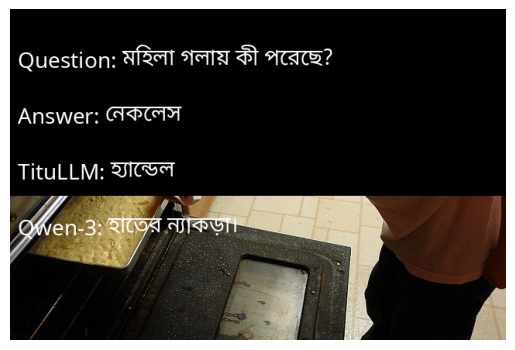

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


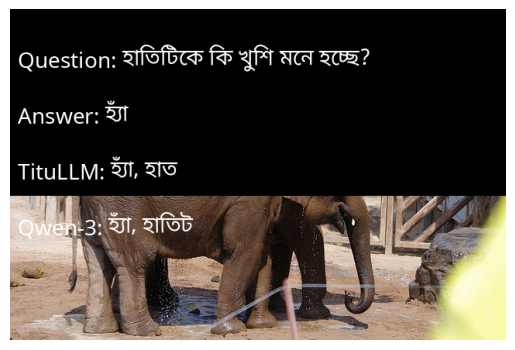

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


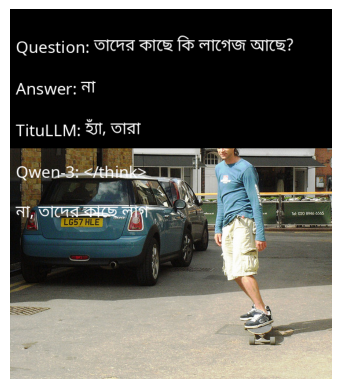

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


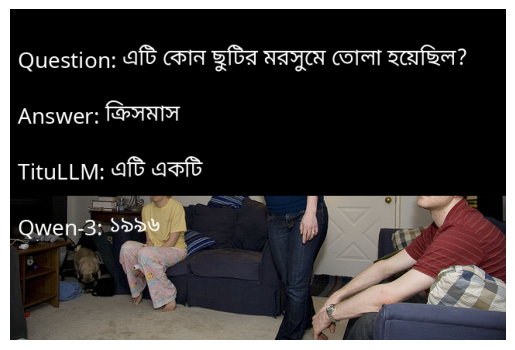

Setting `pad_token_id` to `eos_token_id`:248044 for open-end generation.


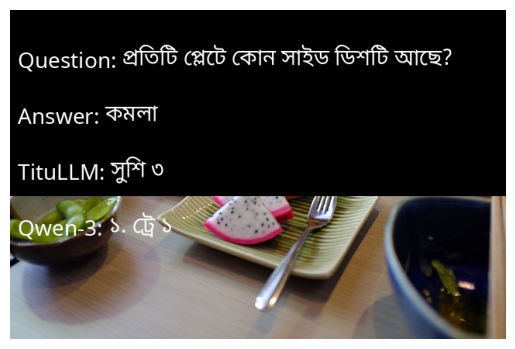

In [85]:
for i in range(5):

    img,q,a=test_set[i]

    pred_eval=preds[i]          # TitulLM
    pred_llama=vqa_llama(img,q) # Qwen

    img=img.copy()
    draw=ImageDraw.Draw(img)

    txt=f"""
Question: {q}

Answer: {a}

TituLLM: {pred_eval}

Qwen-3: {pred_llama}
"""

    draw.rectangle((0,0,img.width,240),fill=(0,0,0))
    draw_mixed_text(draw,10,10,txt)

    plt.imshow(img)
    plt.axis("off")
    plt.savefig(f"Titu_vs_Qwen_{i}.png",dpi=600,bbox_inches="tight")
    plt.show()

In [66]:
!wget https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf

--2026-03-08 23:46:35--  https://github.com/notofonts/noto-fonts/raw/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf [following]
--2026-03-08 23:46:35--  https://raw.githubusercontent.com/notofonts/noto-fonts/main/hinted/ttf/NotoSans/NotoSans-Regular.ttf
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.108.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 569208 (556K) [application/octet-stream]
Saving to: ‘NotoSans-Regular.ttf’

NotoSans-Regular.tt 100%[===================>] 555.87K  --.-KB/s    in 0.04s   

2026-03-08 23:46:35 (12.5 MB/

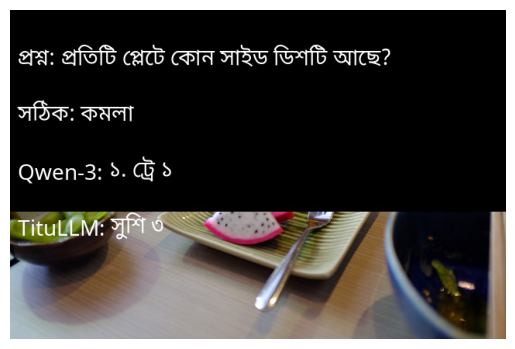

In [77]:
img_copy = img.copy()
draw = ImageDraw.Draw(img_copy)

txt=f"""
প্রশ্ন: {q}

সঠিক: {a}

Qwen-3: {pred_qwen}

TituLLM: {pred_titu}
"""

draw.rectangle((0,0,img.width,260),fill=(0,0,0))

draw_mixed_text(draw,10,10,txt)

plt.imshow(img_copy)
plt.axis("off")
plt.savefig("Comparison.png",dpi=600,bbox_inches="tight")
plt.show()

In [86]:
import numpy as np
from tqdm import tqdm

subset_size=500

qwen_preds=[]
refs=[]

for i in tqdm(range(subset_size)):

    img,q,a=test_set[i]

    pred=vqa_llama(img,q)

    qwen_preds.append(pred.strip())
    refs.append(a.strip())

    torch.cuda.empty_cache()

100%|██████████| 500/500 [09:16<00:00,  1.11s/it]


In [87]:
def normalize(text):
    return text.lower().strip()

yt=[normalize(r) for r in refs]
yp=[normalize(p) for p in qwen_preds]

In [88]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score

acc=accuracy_score(yt,yp)
prec=precision_score(yt,yp,average="macro",zero_division=0)
rec=recall_score(yt,yp,average="macro",zero_division=0)
f1=f1_score(yt,yp,average="macro",zero_division=0)

print("Accuracy:",acc)
print("Precision:",prec)
print("Recall:",rec)
print("F1:",f1)

Accuracy: 0.006
Precision: 0.004629629629629629
Recall: 0.0036008230452674894
F1: 0.0038580246913580245


In [89]:
relaxed=np.mean([r in p or p in r for p,r in zip(yp,yt)])
print("Relaxed Accuracy:",relaxed)

Relaxed Accuracy: 0.376


In [90]:
from nltk.translate.bleu_score import sentence_bleu,SmoothingFunction
from rouge_score import rouge_scorer

smooth=SmoothingFunction().method1
rouge=rouge_scorer.RougeScorer(["rouge1","rougeL"],use_stemmer=True)

bleu=[sentence_bleu([r.split()],p.split(),
        weights=(1,0,0,0),
        smoothing_function=smooth)
        for p,r in zip(yp,yt)]

rouge1=[rouge.score(r,p)["rouge1"].fmeasure for p,r in zip(yp,yt)]
rougeL=[rouge.score(r,p)["rougeL"].fmeasure for p,r in zip(yp,yt)]

print("BLEU:",np.mean(bleu))
print("ROUGE-1:",np.mean(rouge1))
print("ROUGE-L:",np.mean(rougeL))

BLEU: 0.025685714285714284
ROUGE-1: 0.0020714285714285713
ROUGE-L: 0.0020714285714285713


In [94]:
!pip install -U bert-score transformers sentence-transformers -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.2/494.2 kB 8.0 MB/s eta 0:00:00a 0:00:01


In [96]:
from sentence_transformers import SentenceTransformer
import torch

bert_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda"
)

# 👉 Qwen
pred_emb_qwen = bert_model.encode(qwen_preds,convert_to_tensor=True)
ref_emb       = bert_model.encode(refs,convert_to_tensor=True)

cos_scores_qwen = torch.nn.functional.cosine_similarity(pred_emb_qwen,ref_emb)

print("Qwen BERTScore (cosine):",cos_scores_qwen.mean().item())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Qwen BERTScore (cosine): 0.6776696443557739


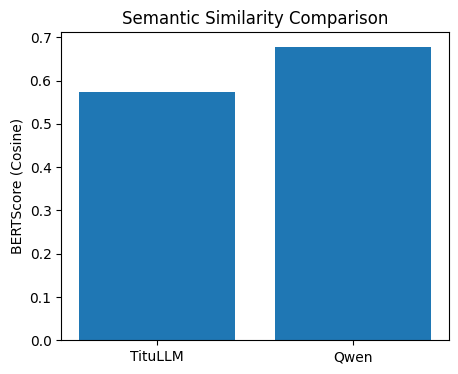

In [99]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,4))

plt.bar(["TituLLM","Qwen"],
        [cos_scores.mean().item(),
         cos_scores_qwen.mean().item()])

plt.ylabel("BERTScore (Cosine)")
plt.title("Semantic Similarity Comparison")

plt.savefig("BERTScore_compare.png",dpi=600,bbox_inches="tight")
plt.show()

In [97]:
hallucination=np.mean([p not in r for p,r in zip(yp,yt)])
print("Hallucination Rate:",hallucination)

Hallucination Rate: 0.952


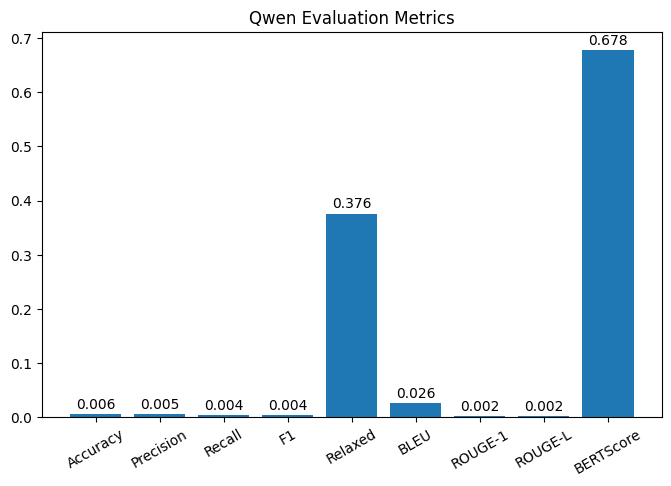

In [105]:
import matplotlib.pyplot as plt

metrics=["Accuracy","Precision","Recall","F1","Relaxed","BLEU","ROUGE-1","ROUGE-L","BERTScore"]

values=[acc,prec,rec,f1,relaxed,
        np.mean(bleu),
        np.mean(rouge1),
        np.mean(rougeL),
        cos_scores_qwen.mean().item()]   # ✅ FIXED

plt.figure(figsize=(8,5))
plt.bar(metrics,values)
plt.xticks(rotation=30)
plt.title("Qwen Evaluation Metrics")

# 👉 add numbers (recommended for paper)
for i,v in enumerate(values):
    plt.text(i,v+0.01,f"{v:.3f}",ha="center")

plt.savefig("Qwen_metrics.png",dpi=600,bbox_inches="tight")
plt.show()

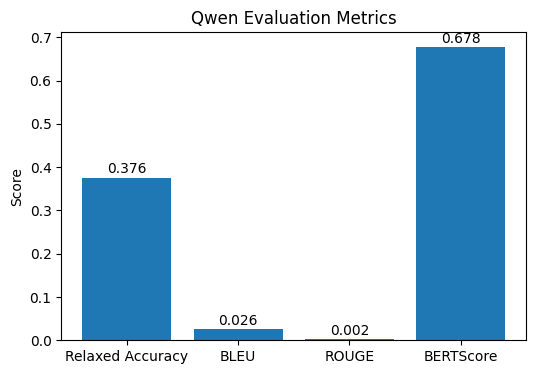

In [100]:
import matplotlib.pyplot as plt
import numpy as np

# ✅ use YOUR computed values
qwen_relaxed = relaxed
qwen_bleu    = np.mean(bleu)
qwen_rouge   = np.mean(rougeL)
qwen_bert    = cos_scores_qwen.mean().item()   # 🔥 FIX HERE

metrics=["Relaxed Accuracy","BLEU","ROUGE","BERTScore"]
values=[qwen_relaxed,qwen_bleu,qwen_rouge,qwen_bert]

plt.figure(figsize=(6,4))
plt.bar(metrics,values)

plt.title("Qwen Evaluation Metrics")
plt.ylabel("Score")

for i,v in enumerate(values):
    plt.text(i,v+0.01,f"{v:.3f}",ha="center")

plt.savefig("Qwen_only_metrics.png",dpi=600,bbox_inches="tight")
plt.show()

In [107]:
import numpy as np
from nltk.translate.bleu_score import sentence_bleu,SmoothingFunction
from rouge_score import rouge_scorer

# normalize
def norm(x): return x.lower().strip()

yt=[norm(r) for r in refs]
yp_titu=[norm(p) for p in preds]

# ✅ RELAXED ACCURACY
relaxed_acc_titu=np.mean([r in p or p in r for p,r in zip(yp_titu,yt)])

# ✅ BLEU
smooth=SmoothingFunction().method1
bleu_titu=[sentence_bleu([r.split()],p.split(),
            weights=(1,0,0,0),
            smoothing_function=smooth)
            for p,r in zip(yp_titu,yt)]

# ✅ ROUGE
rouge=rouge_scorer.RougeScorer(["rougeL"],use_stemmer=True)
rouges_titu=[rouge.score(r,p)["rougeL"].fmeasure for p,r in zip(yp_titu,yt)]

print("Titu done ✅")

Titu done ✅


In [108]:
from sentence_transformers import SentenceTransformer
import torch

bert_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2",
    device="cuda"
)

pred_emb_titu = bert_model.encode(preds,convert_to_tensor=True)
ref_emb       = bert_model.encode(refs,convert_to_tensor=True)

cos_scores_titu=torch.nn.functional.cosine_similarity(pred_emb_titu,ref_emb)

print("Titu BERTScore done ✅")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Titu BERTScore done ✅


In [110]:
titu_metrics = {
    "Relaxed Accuracy": relaxed_acc_titu,
    "BLEU": np.mean(bleu_titu),
    "ROUGE": np.mean(rouges_titu),
    "BERTScore": cos_scores_titu.mean().item()
}

qwen_metrics = {
    "Relaxed Accuracy": qwen_relaxed,
    "BLEU": np.mean(qwen_bleu),
    "ROUGE": np.mean(qwen_rouge),
    "BERTScore": cos_scores_qwen.mean().item()
}

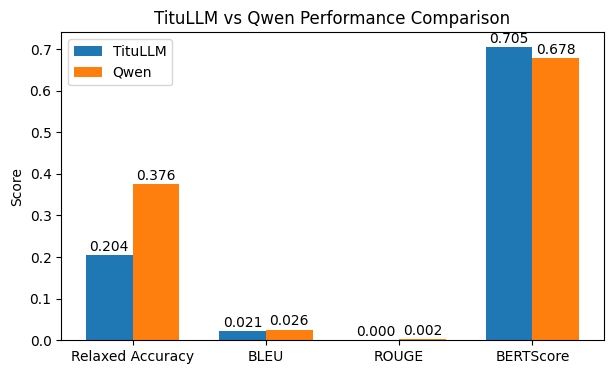

In [111]:
import numpy as np
import matplotlib.pyplot as plt

labels=list(titu_metrics.keys())

titu_vals=list(titu_metrics.values())
qwen_vals=list(qwen_metrics.values())

x=np.arange(len(labels))
w=0.35

plt.figure(figsize=(7,4))

bars1=plt.bar(x-w/2,titu_vals,w,label="TituLLM")
bars2=plt.bar(x+w/2,qwen_vals,w,label="Qwen")

plt.xticks(x,labels)
plt.ylabel("Score")
plt.title("TituLLM vs Qwen Performance Comparison")
plt.legend()

# ✅ dynamic value labels
for bars in [bars1,bars2]:
    for bar in bars:
        yval=bar.get_height()
        plt.text(bar.get_x()+bar.get_width()/2,
                 yval+0.01,
                 f"{yval:.3f}",
                 ha="center")

plt.savefig("Titu_vs_Qwen_metrics.png",dpi=600,bbox_inches="tight")
plt.show()

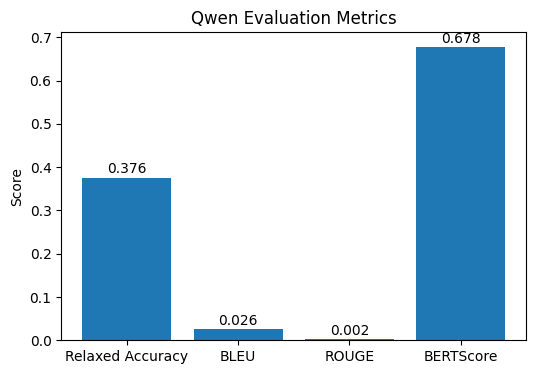

In [112]:
metrics_names=list(qwen_metrics.keys())
metrics_values=list(qwen_metrics.values())

plt.figure(figsize=(6,4))

bars=plt.bar(metrics_names,metrics_values)

for bar in bars:
    yval=bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2,
             yval+0.01,
             f"{yval:.3f}",
             ha="center")

plt.title("Qwen Evaluation Metrics")
plt.ylabel("Score")

plt.savefig("Qwen_metrics.png",dpi=600,bbox_inches="tight")
plt.show()

In [103]:
import numpy as np

def hallucination_rate(preds,refs):

    def norm(x):
        return x.lower().strip()

    halluc=[]

    for p,r in zip(preds,refs):

        p=norm(p)
        r=norm(r)

        # ✅ relaxed correctness
        if (p in r) or (r in p):
            halluc.append(0)
            continue

        # ✅ token overlap check
        p_tokens=set(p.split())
        r_tokens=set(r.split())

        overlap=len(p_tokens & r_tokens)

        halluc.append(0 if overlap>0 else 1)

    return np.mean(halluc)

In [104]:
hall_titu=hallucination_rate(preds,refs)
hall_qwen=hallucination_rate(qwen_preds,refs)

print("TituLLM Hallucination:",hall_titu)
print("Qwen Hallucination:",hall_qwen)

TituLLM Hallucination: 0.796
Qwen Hallucination: 0.618
